Analyse peak number of daily new cases in Germany,France and Italy. Which country experienced the highest single day surge and when did it occur?

In [1]:
import pandas as pd
deaths=pd.read_excel(r"C:\Users\sonali\Downloads\covid_19_dataset.xlsx",sheet_name="covid_19_deaths_v1")
confirmed=pd.read_excel(r"C:\Users\sonali\Downloads\covid_19_dataset.xlsx",sheet_name="covid_19_confirmed_v1")
recovered=pd.read_excel(r"C:\Users\sonali\Downloads\covid_19_dataset.xlsx",sheet_name="covid_19_recovered_v1")
confirmed['Province/State']=confirmed['Province/State'].fillna("All Provinces")
confirmed=confirmed.ffill()
confirmed=confirmed.drop(columns=["Lat", "Long"])
df_country=confirmed.groupby('Country/Region').sum(numeric_only=True)    #aggregate country-wise
df_ts=df_country.T                                                      #Convert to time series(DATES AS INDEX)
df_ts.index=pd.to_datetime(df_ts.index,format="%m/%d/%y")
df_ts=df_ts.sort_index()                                                #sort the index
daily_cases=df_ts.diff()                                                #convert cumulative-- daily new cases
daily_cases=daily_cases.fillna(0)                                      #remove first row which is nan due to diff()
daily_cases=daily_cases.astype(int)
daily_cases[daily_cases < 0]=0
countries=["Germany","France","Italy"]                                 #select countries
result={}
for country in countries:
    peak_value=daily_cases[country].max()
    peak_date=daily_cases[country].idxmax()

    result[country]={
        "Peak Cases": int(peak_value),
        "Date": peak_date
        }
for country,data in result.items():
    print(f"{country}: {data['Peak Cases']} cases on {data['Date'].date()}")

Germany: 592770 cases on 2021-06-05
France: 1163615 cases on 2020-12-11
Italy: 911566 cases on 2020-01-12


Compare the recovery rates(recoveries/confirmed cases) between Canada and Australia as of December 31,2020. Which country showed better management of the pandemic according to this metric?

Canada: 84.47%
Australia: 79.38%

Better Recovery Rate: Canada


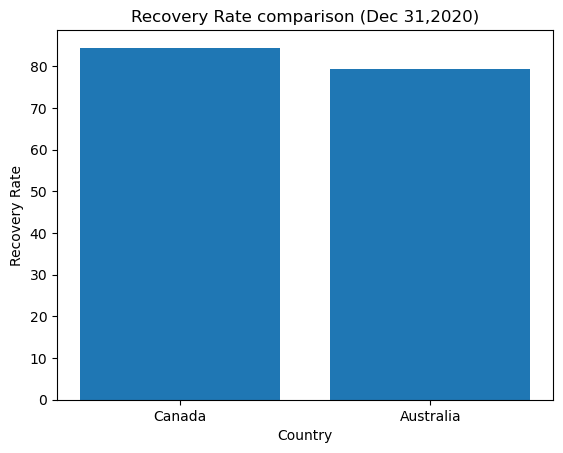

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
deaths=pd.read_excel(r"C:\Users\sonali\Downloads\covid_19_dataset.xlsx",sheet_name="covid_19_deaths_v1")
confirmed=pd.read_excel(r"C:\Users\sonali\Downloads\covid_19_dataset.xlsx",sheet_name="covid_19_confirmed_v1")
recovered=pd.read_excel(r"C:\Users\sonali\Downloads\covid_19_dataset.xlsx",sheet_name="covid_19_recovered_v1")
#drop unwanted columns
confirmed=confirmed.drop(columns=['Lat','Long'],errors='ignore')
recovered=recovered.drop(columns=['Lat','Long'],errors='ignore')
confirmed['Province/State']=confirmed['Province/State'].fillna("All Provinces")
recovered['Province/State']=recovered['Province/State'].fillna("All Provinces")
#aggregate countrywise
confirmed_country=confirmed.groupby("Country/Region").sum(numeric_only=True)
recovered_country=recovered.groupby("Country/Region").sum(numeric_only=True)
date_col='12/31/20'
countries=['Canada','Australia']
result={}
for country in countries:
    confirmed_cases=confirmed_country.loc[country,date_col]
    recovered_cases=recovered_country.loc[country,date_col]
    recovery_rate=recovered_cases/confirmed_cases
    result[country]={
         "Confirmed":int(confirmed_cases),
         "Recovered":int(recovered_cases),
         "Recovery Rate":recovery_rate}
for country,data in result.items():
    print(f"{country}: {data['Recovery Rate']:.2%}")
best_country=max(result,key=lambda x:result[x]['Recovery Rate'])
print(f"\nBetter Recovery Rate: {best_country}")
#ploting bar chart for this using matplotlib
df=pd.DataFrame(result)
df=df.T.reset_index()
df=df.rename(columns={'index':'Country'})
plt.figure()
plt.bar(df['Country'],df['Recovery Rate']*100)
plt.title("Recovery Rate comparison (Dec 31,2020)")
plt.xlabel("Country")
plt.ylabel("Recovery Rate")
plt.show()

What is the distribution of death rates(deaths/confirmed cases) among provinces in Canada? Identify the province with the highest and the lowest death rate as of the latest data point.

Highest Death rate: Province        Quebec
Death Rate    3.008969
Name: 11, dtype: object.
Lowest Death rate: Province      Newfoundland and Labrador
Death Rate                     0.460829
Name: 5, dtype: object.


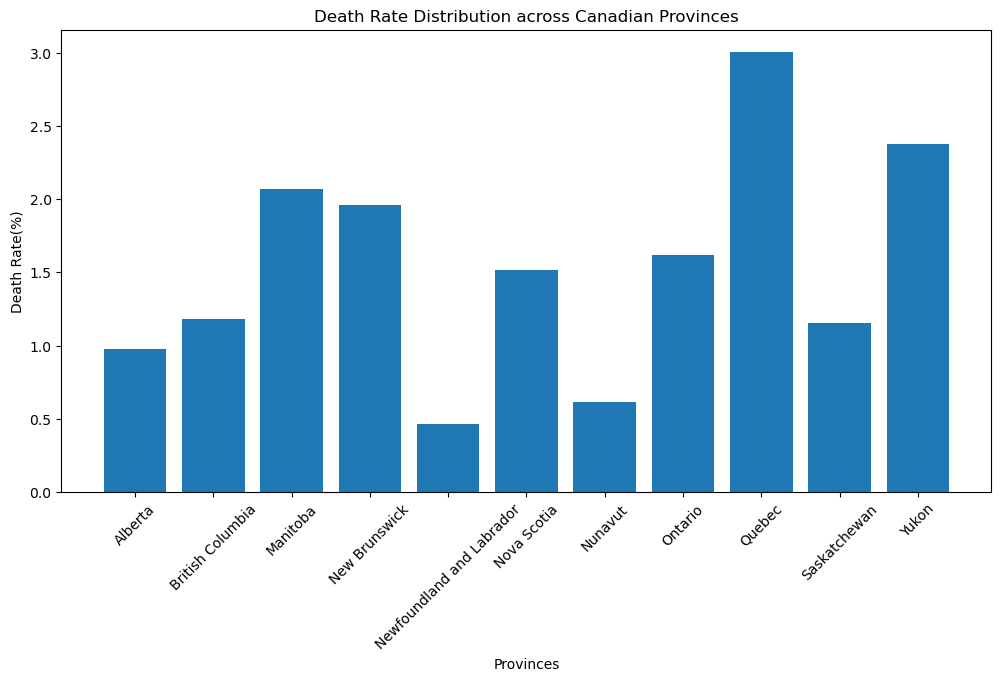

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
deaths=pd.read_excel(r"C:\Users\sonali\Downloads\covid_19_dataset.xlsx",sheet_name="covid_19_deaths_v1")
confirmed=pd.read_excel(r"C:\Users\sonali\Downloads\covid_19_dataset.xlsx",sheet_name="covid_19_confirmed_v1")
confirmed=confirmed.drop(columns=['Lat','Long'],errors='ignore')
deaths=deaths.drop(columns=['Lat','Long'],errors='ignore')
confirmed['Province/State']=confirmed['Province/State'].fillna("All Provinces")
deaths['Province/State']=deaths['Province/State'].fillna("All Provinces")
canada_confirmed=confirmed[confirmed['Country/Region']=='Canada']
canada_deaths=deaths[deaths['Country/Region']=='Canada']
#Aggregate by Province
confirmed_prov=canada_confirmed.groupby('Province/State').sum(numeric_only=True)
deaths_prov=canada_deaths.groupby('Province/State').sum(numeric_only=True)
#take latest date
latest_col=confirmed_prov.columns[-1]
#compute death rate
valid = confirmed_prov[latest_col]>0
death_rate=(deaths_prov[latest_col][valid]/confirmed_prov[latest_col][valid])*100
death_rate=death_rate.replace([float('inf'), -float('inf')],0)
death_rate=death_rate.fillna(0)
#Convert to dataframe
df_death_rate=death_rate.reset_index()
df_death_rate.columns=['Province','Death Rate']
valid_df=df_death_rate[df_death_rate["Death Rate"] > 0]
max_prov=valid_df.loc[valid_df["Death Rate"].idxmax()]
min_prov=valid_df.loc[valid_df["Death Rate"].idxmin()]
print(f"Highest Death rate: {max_prov}.")
print(f"Lowest Death rate: {min_prov}.")
#PLOTTING BAR GRAPH 
plt.figure(figsize=(12,6))
plt.bar(valid_df['Province'],valid_df['Death Rate'])
plt.title("Death Rate Distribution across Canadian Provinces")
plt.xlabel("Provinces")
plt.ylabel("Death Rate(%)")
plt.xticks(rotation=45)
plt.show()

What is the total number of deaths reported per country up to date?

In [4]:
import pandas as pd
deaths_long=pd.read_excel(r"C:\Users\sonali\Downloads\deathsnew.xlsx")
total_deaths=deaths_long.groupby('Country/Region')['Deaths'].max()
print(total_deaths)

Country/Region
Afghanistan           2899.0
Albania               2449.0
Algeria               3460.0
Andorra                127.0
Angola                 757.0
                       ...  
Vietnam                 47.0
West Bank and Gaza    3492.0
Yemen                 1319.0
Zambia                1276.0
Zimbabwe              1594.0
Name: Deaths, Length: 193, dtype: float64


What are the top 5 countries with the highest average daily deaths?

    Country/Region  Avg Daily Deaths
179             US           1203.05
23          Brazil            933.31
79           India            659.86
115         Mexico            452.34
85           Italy            255.06


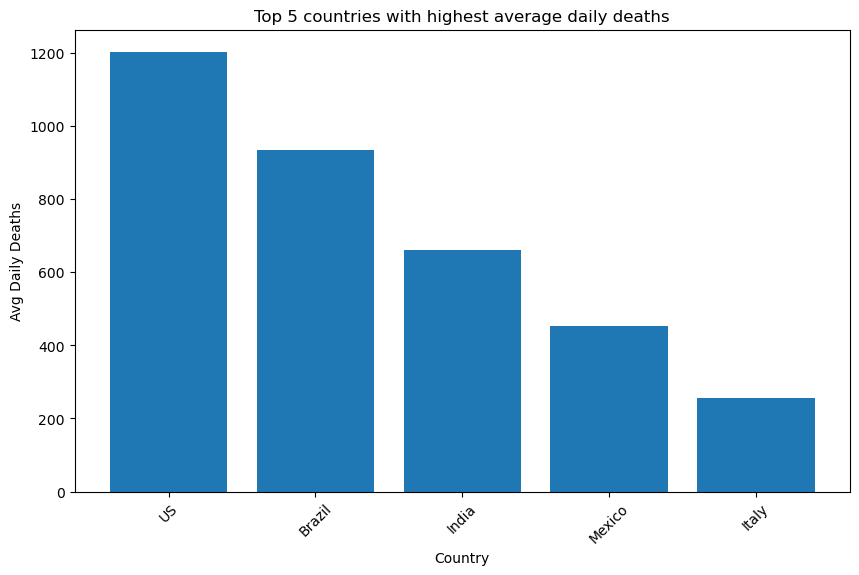

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
deaths_long=pd.read_excel(r"C:\Users\sonali\Downloads\deathsnew.xlsx")
deaths_long=deaths_long.sort_values(['Country/Region','Date'])
deaths_long['Daily_deaths']=deaths_long.groupby('Country/Region')['Deaths'].diff()
#replace negative values and nan to 0
deaths_long['Daily_deaths']=deaths_long['Daily_deaths'].fillna(0)
deaths_long['Daily Deaths']=deaths_long['Daily_deaths'].clip(lower=0)
avg_daily_deaths=deaths_long.groupby('Country/Region')['Daily_deaths'].mean()
avg_daily_deaths=avg_daily_deaths.reset_index(name='Avg Daily Deaths')
top_5=round(avg_daily_deaths.sort_values(by='Avg Daily Deaths',ascending=False).head(5),2)
print(top_5)
#plot a bar chart 
plt.figure(figsize=(10,6))
plt.bar(top_5['Country/Region'],top_5['Avg Daily Deaths'])
plt.title("Top 5 countries with highest average daily deaths")
plt.xlabel("Country")
plt.ylabel("Avg Daily Deaths")
plt.xticks(rotation=45)
plt.show()

How have the total deaths evolved over time in US?

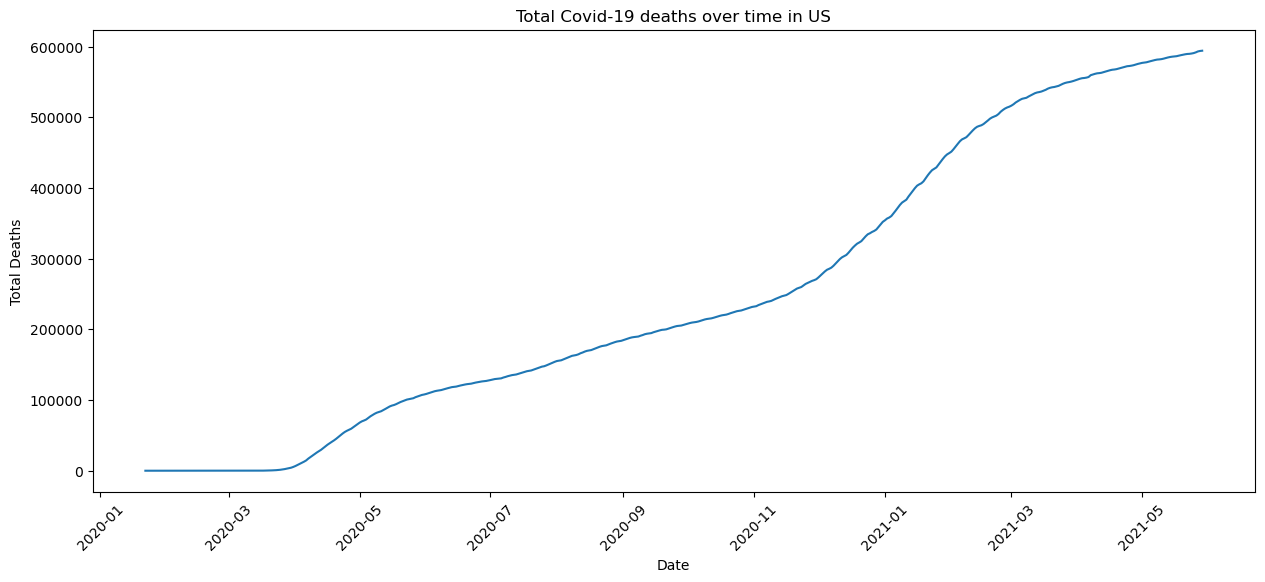

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
deaths_long=pd.read_excel(r"C:\Users\sonali\Downloads\deathsnew.xlsx")
deaths_long=deaths_long[deaths_long['Country/Region']=='US']
us_daily=deaths_long.groupby('Date')['Deaths'].sum().reset_index()
#us_daily['Deaths']=us_daily['Deaths'].cummax()
#print(us_daily)
#plot deaths over time
plt.figure(figsize=(15,6))
plt.plot(deaths_long['Date'],deaths_long['Deaths'])
plt.title('Total Covid-19 deaths over time in US')
plt.xlabel('Date')
plt.ylabel('Total Deaths')
plt.xticks(rotation=45)
plt.show()

In [ ]:
Analyze monthly sum of confirmed cases,death and recoveries for countries to understand the progression of pandemic.

In [ ]:
import pandas as pd
merged=pd.read_excel(r"C:\Users\sonali\Downloads\merged_covid.xlsx")
merged=merged.sort_values(['Country/Region','Date'])
merged['Daily_Confirmed']=merged.groupby('Country/Region')['Confirmed'].diff().fillna(0)
merged['Daily_Deaths']=merged.groupby('Country/Region')['Deaths'].diff().fillna(0)
merged['Daily_Recovered']=merged.groupby('Country/Region')['Recovered'].diff().fillna(0)
merged['Daily_Recovered']=merged['Daily_Recovered'].clip(lower=0)
merged['Month']=merged['Date'].dt.to_period('M')
monthly=merged.groupby(['Country/Region','Month'],as_index=False)[['Daily_Confirmed','Daily_Deaths','Daily_Recovered']].sum()
monthly.to_excel(r"C:\Users\sonali\Downloads\monthly_covid.xlsx",index=False)

 Redo the analysis for US,Italy,Brazil

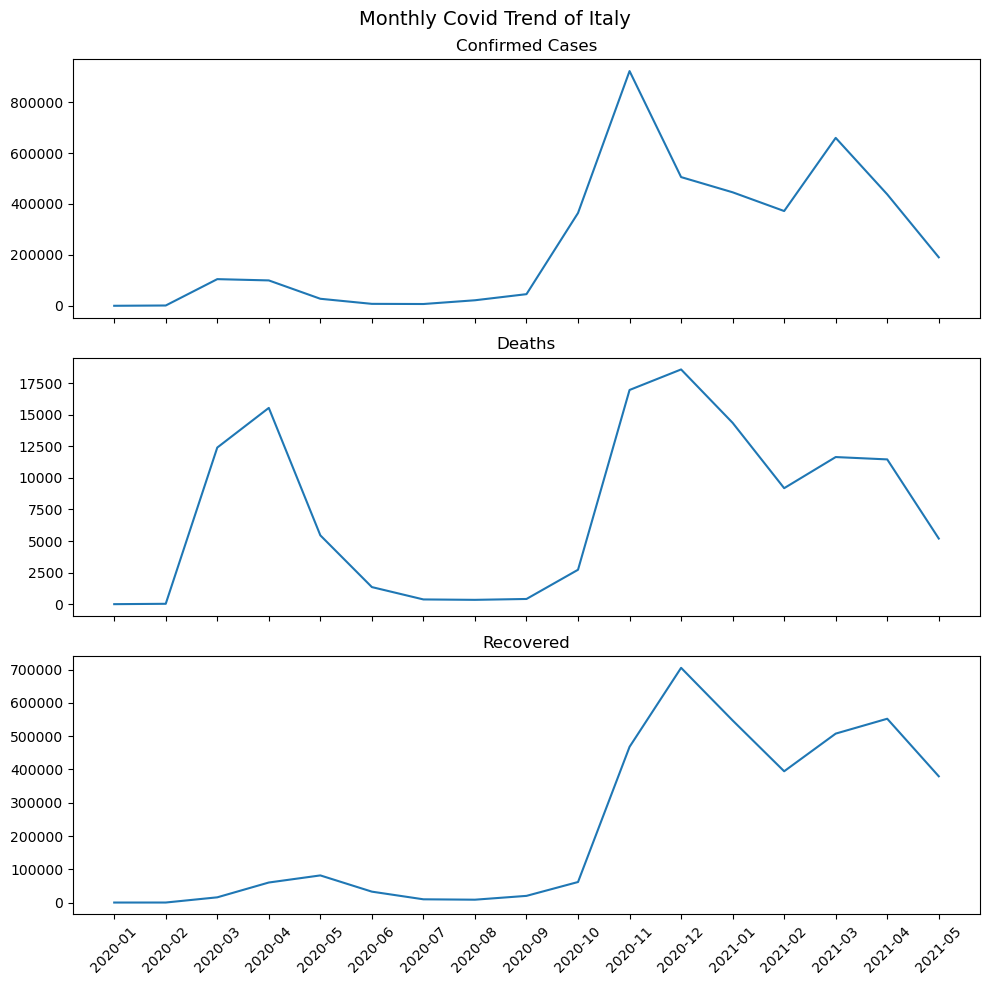

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
country='Italy'
data=pd.read_excel(r"C:\Users\sonali\Downloads\monthly_covid.xlsx")
data=data[data['Country/Region']==country]
fig,axes=plt.subplots(3,1,figsize=(10, 10),sharex=True)
# --- Confirmed ---
axes[0].plot(data['Month'].astype(str),data['Daily_Confirmed'])
axes[0].set_title('Confirmed Cases')
axes[0].ticklabel_format(style='plain',axis='y')
# --- Deaths ---
axes[1].plot(data['Month'].astype(str),data['Daily_Deaths'])
axes[1].set_title('Deaths')
axes[1].ticklabel_format(style='plain',axis='y')
# --- Recovered ---
axes[2].plot(data['Month'].astype(str),data['Daily_Recovered'])
axes[2].set_title('Recovered')
axes[2].ticklabel_format(style='plain',axis='y')
plt.xticks(rotation=45)
plt.suptitle(f"Monthly Covid Trend of {country}",fontsize=14)
plt.tight_layout()
plt.show()

For the combined dataset, identify three countries with the highest average death rates(death/confirmed cases) throughout 2020. What might this indicate about the pandemic's impact in these countries?

Top 3 countries with highest death rate (2020):
     Country/Region  Death Rate
56            Italy    9.464157
107           Sudan    8.807526
118  United Kingdom    8.474790


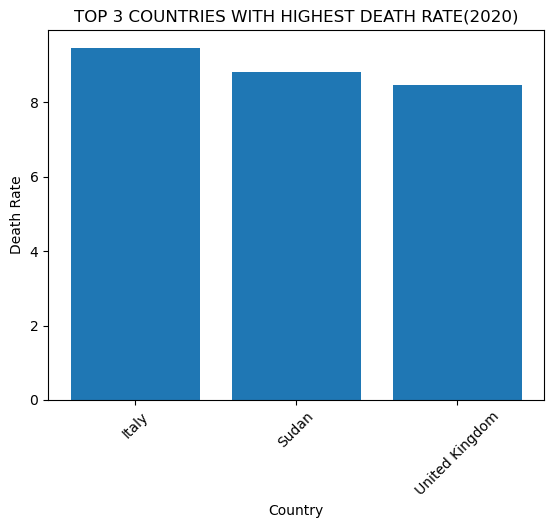

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
merged=pd.read_excel(r"C:\Users\sonali\Downloads\merged_covid.xlsx")
# Filter 2020
df_2020 = merged[
    (merged['Date']>='2020-01-01')&(merged['Date']<='2020-12-31')].copy()
# Remove low-data countries
valid=df_2020.groupby('Country/Region')['Confirmed'].max()>10000
df_2020=df_2020[df_2020['Country/Region'].isin(valid[valid].index)]
# Compute death rate
df_2020['Death_Rate']=(df_2020['Deaths']/df_2020['Confirmed'])*100
df_2020['Death_Rate']=df_2020['Death_Rate'].replace([float('inf'),-float('inf')],0)
df_2020['Death_Rate']=df_2020['Death_Rate'].fillna(0)
death_rate=df_2020.groupby('Country/Region')['Death_Rate'].mean()
death_rate=death_rate.reset_index(name="Death Rate")
# Get top 3 countries
top3=death_rate.sort_values(by='Death Rate',ascending=False).head(3)
print("Top 3 countries with highest death rate (2020):")
print(top3)

#PLOT ON CHART
plt.figure()
plt.bar(top3['Country/Region'],top3['Death Rate'])
plt.title("TOP 3 COUNTRIES WITH HIGHEST DEATH RATE(2020)")
plt.xlabel("Country")
plt.ylabel("Death Rate")
plt.xticks(rotation=45)
plt.show()

Compare the total number of recoveries to total number of deaths in South Africe. What can this tell us about the outcomes of covid 19 cases in the country?

South Africa:
Total Recoveries: 1554184
Total Deaths: 56363
Recovery-to-Death Ratio: 27.57


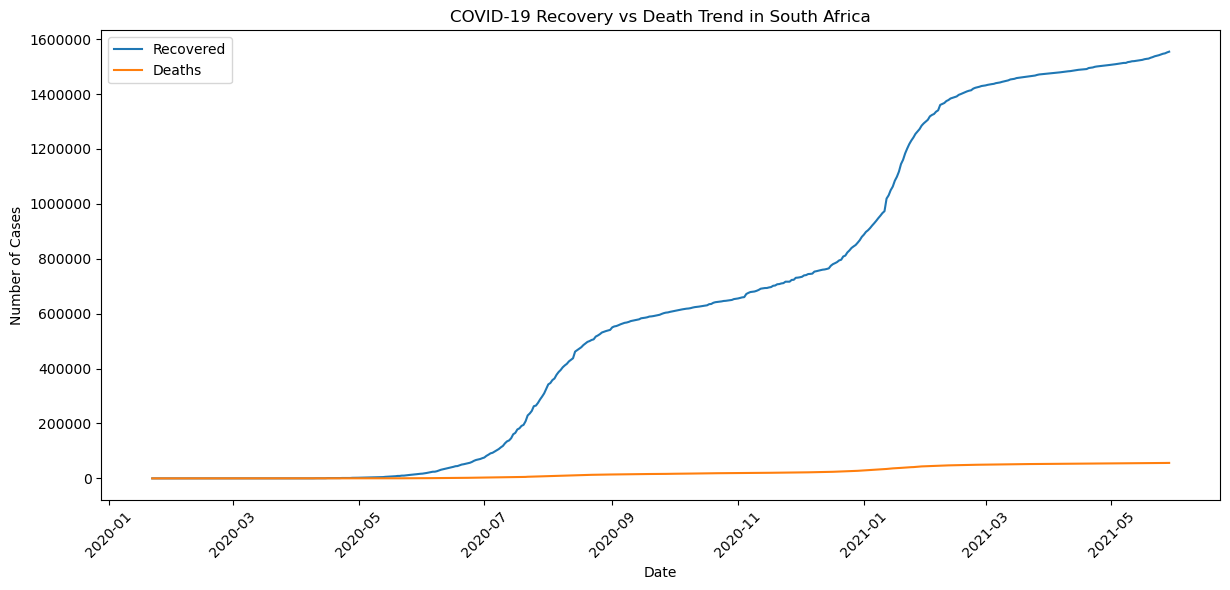

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
merged=pd.read_excel(r"C:\Users\sonali\Downloads\merged_covid.xlsx")
#Take only South Africa
merged=merged[merged['Country/Region']=='South Africa']
# Get the values of most recent date
latest=merged.sort_values('Date').groupby('Country/Region').last()
total_deaths=latest['Deaths'].values[0]
total_recovered=latest['Recovered'].values[0]
print("South Africa:")
print(f"Total Recoveries: {total_recovered}")
print(f"Total Deaths: {total_deaths}")

# Recovery-to-death ratio
ratio=total_recovered/total_deaths if total_deaths!=0 else None
print(f"Recovery-to-Death Ratio: {ratio:.2f}")


#PLOT RECOVERED VS DEATH CASES OVER TIME
merged=merged.groupby('Date', as_index=False)[['Recovered','Deaths']].sum()
plt.figure(figsize=(12,6))
plt.plot(merged['Date'],merged['Recovered'],label='Recovered')
plt.plot(merged['Date'],merged['Deaths'],label='Deaths')
plt.title("COVID-19 Recovery vs Death Trend in South Africa")
plt.xlabel("Date")
plt.ylabel("Number of Cases")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.ticklabel_format(style='plain',axis='y')
plt.show()

Analyse the ratio of recoveries to confirmed cases for the United States on a monthly basis from March 2020 to May 2021. Which month experienced the highest ratio and what could be the reasons.

Highest Recovery Ratio Month:
Month: 2020-09
Recovery Ratio: 0.543


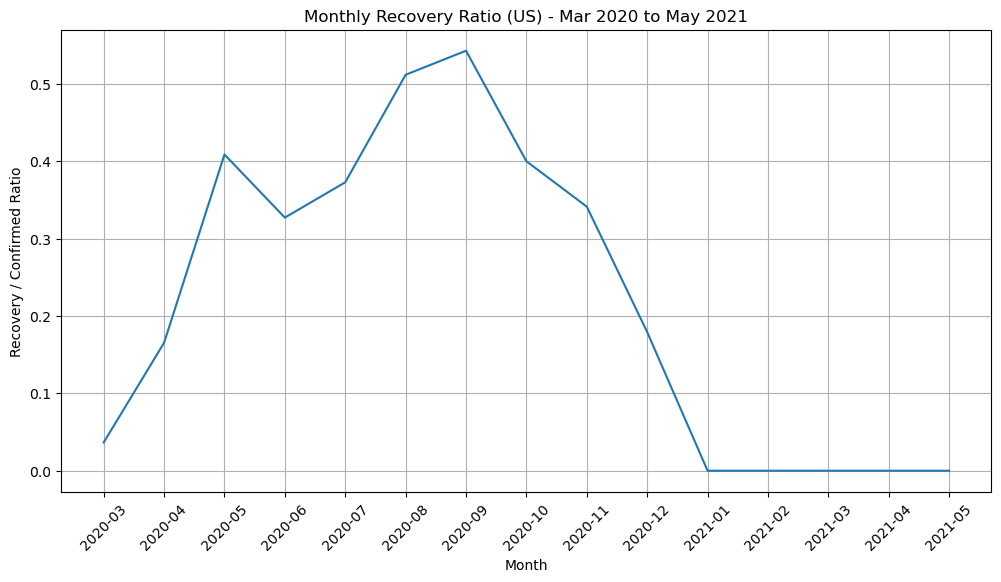

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
merged=pd.read_excel(r"C:\Users\sonali\Downloads\merged_covid.xlsx")
merged['Date']=pd.to_datetime(merged['Date'])
merged=merged[merged['Country/Region']=='US']
merged=merged[(merged['Date']>='2020-03-01')&(merged['Date']<='2021-05-31')]
merged=merged.sort_values('Date')
# Create Month Column
merged['Month']=merged['Date'].dt.to_period('M')
#  Convert cumulative daily
merged['Daily_Confirmed']=merged['Confirmed'].diff().fillna(0)
merged['Daily_Recovered']=merged['Recovered'].diff().fillna(0)
# Remove negative correction
merged['Daily_Confirmed']=merged['Daily_Confirmed'].clip(lower=0)
merged['Daily_Recovered']=merged['Daily_Recovered'].clip(lower=0)
monthly=merged.groupby('Month',as_index=False)[['Daily_Confirmed','Daily_Recovered']].sum()
# Recovery Ratio
monthly['Recovery_Ratio']=(monthly['Daily_Recovered']/monthly['Daily_Confirmed']).replace([float('inf'), -float('inf')], 0).fillna(0)
# Convert month to string for plotting
monthly['Month']=monthly['Month'].astype(str)
# Find month with highest recovery ratio
max_month=monthly.loc[monthly['Recovery_Ratio'].idxmax()]
print("Highest Recovery Ratio Month:")
print(f"Month: {max_month['Month']}")
print(f"Recovery Ratio: {max_month['Recovery_Ratio']:.3f}")

# PLOT THE LINE CHART
plt.figure(figsize=(12,6))
plt.plot(monthly['Month'], monthly['Recovery_Ratio'])
plt.title("Monthly Recovery Ratio (US) - Mar 2020 to May 2021")
plt.xlabel("Month")
plt.ylabel("Recovery / Confirmed Ratio")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()